# Installing Dependencies


In [1]:
%pip install tensorflow numpy pandas scikit-learn matplotlib pillow


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Data Load

## ⚙️ Path Configuration

**Change `BASE_DIR` below to match where you extracted `img.zip`.**

Expected structure after extraction:
```
BASE_DIR/
  img/
    001bd5563b4511f0b16c00155d672fff.png
    d13cde743b4411f0b16c00155d672fff.jpg
    ...
  train-label.csv
  test-label.csv
  submission.csv
```


In [2]:
import os
import numpy as np
import pandas as pd

# ─────────────────────────────────────────────────────────────
#  CHANGE THIS to your local path where the dataset lives
# ─────────────────────────────────────────────────────────────
BASE_DIR = '.'          # e.g. '/Users/yourname/Downloads/knu_ml'
IMG_DIR  = os.path.join(BASE_DIR, 'img')  # folder containing all images

TRAIN_LABEL = pd.read_csv(os.path.join(BASE_DIR, 'train-label.csv'), index_col='id')
TEST_LABEL  = pd.read_csv(os.path.join(BASE_DIR, 'test-label.csv'),  index_col='id')

TRAIN_DATA = None   # placeholder – set after preprocessing
TEST_DATA  = None   # placeholder – set after preprocessing

print('Train samples:', len(TRAIN_LABEL))
print('Test  samples:', len(TEST_LABEL))
print('Label distribution (train):')
print(TRAIN_LABEL['label'].value_counts().sort_index())

Train samples: 1385
Test  samples: 1386
Label distribution (train):
label
0    707
1    678
Name: count, dtype: int64


## 1. Imports & Reproducibility


In [3]:
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Mixed precision: faster on Apple Silicon & GPUs ──────────
# Speeds up training without sacrificing accuracy
keras.mixed_precision.set_global_policy('mixed_float16')

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))
print('Mixed precision policy:', keras.mixed_precision.global_policy().name)

TensorFlow version: 2.21.0
GPUs available: []
Mixed precision policy: mixed_float16


## 2. Hyperparameters


In [4]:
# ── Image settings ───────────────────────────────────────────
# 224×224 preserves more detail than 128×128 — memes contain text and
# fine-grained art style cues that get destroyed at lower resolution.
IMG_HEIGHT   = 224
IMG_WIDTH    = 224
IMG_CHANNELS = 3

# ── Training settings ────────────────────────────────────────
BATCH_SIZE   = 32
EPOCHS       = 60        # more epochs; early stopping guards against overfitting
LR_INIT      = 5e-4      # slightly lower; CosineDecayRestarts handles warmup
DROPOUT_RATE = 0.4
L2_LAMBDA    = 5e-5
LABEL_SMOOTH = 0.05      # label smoothing: prevents overconfident predictions

# ── Validation split ─────────────────────────────────────────
VAL_SPLIT    = 0.15

# ── TTA settings ─────────────────────────────────────────────
TTA_STEPS    = 8         # number of augmented views to average at inference

## 3. Data Loading & Preprocessing

**Key improvement over 1d:** Per-channel z-normalization (zero-mean, unit-variance
per channel computed on the training set) is applied instead of a simple /255 scale.
This removes global illumination bias and makes the network's first-layer weights
learn shape/texture features rather than absorbing channel offset.

Doom images tend to be dark and desaturated; Animal Crossing images are bright
and pastels. Per-channel standardization forces the network to rely on
**structural** and **texture** cues instead of just color brightness shortcuts,
leading to more robust features.


In [5]:
def load_image(filepath: str) -> np.ndarray:
    """Load one image, convert to RGB, resize to (IMG_HEIGHT, IMG_WIDTH).
    Uses LANCZOS resampling — higher quality than BILINEAR for downscaling,
    preserving edges and text in meme images.
    Returns float32 in [0, 1].
    """
    img = Image.open(filepath).convert('RGB')
    img = img.resize((IMG_WIDTH, IMG_HEIGHT), Image.LANCZOS)  # LANCZOS > BILINEAR
    return np.array(img, dtype=np.float32) / 255.0


def load_dataset(label_df: pd.DataFrame, img_dir: str, has_labels: bool = True):
    """Load all images listed in label_df.
    Returns (X, y) where X is (N, H, W, C) float32 in [0,1], y is (N,) int32 or None.
    """
    images, labels = [], []
    missing = 0
    for row_id, row in label_df.iterrows():
        path = os.path.join(img_dir, row['file'])
        if not os.path.exists(path):
            missing += 1
            continue
        images.append(load_image(path))
        if has_labels:
            labels.append(int(row['label']))
    if missing > 0:
        print(f'  ⚠️  {missing} images not found – skipped')
    X = np.stack(images).astype(np.float32)
    y = np.array(labels, dtype=np.int32) if has_labels else None
    return X, y


print('Loading train images …')
X_all, y_all = load_dataset(TRAIN_LABEL, IMG_DIR, has_labels=True)
print(f'  Train shape: {X_all.shape}, labels: {y_all.shape}')

print('Loading test images …')
X_test, _ = load_dataset(TEST_LABEL, IMG_DIR, has_labels=False)
print(f'  Test  shape: {X_test.shape}')

TRAIN_DATA = X_all
TEST_DATA  = X_test

Loading train images …
  Train shape: (1385, 224, 224, 3), labels: (1385,)
Loading test images …
  Test  shape: (1386, 224, 224, 3)


## 4. Per-Channel Normalization (Standardization)

Compute mean and std **only on the training set** (to avoid data leakage),
then apply to train, val, and test.
This is standard practice in image classification pipelines (ImageNet models
all use channel-wise mean subtraction).


In [6]:
# Compute per-channel statistics on the full training set
# Shape of X_all: (N, H, W, C) — average over N, H, W axes
channel_mean = X_all.mean(axis=(0, 1, 2), keepdims=True)  # (1,1,1,3)
channel_std  = X_all.std(axis=(0, 1, 2),  keepdims=True)  # (1,1,1,3)
channel_std  = np.maximum(channel_std, 1e-7)  # avoid division by zero

print(f'Channel mean (R,G,B): {channel_mean.flatten().round(4)}')
print(f'Channel std  (R,G,B): {channel_std.flatten().round(4)}')

# Apply normalization — pixels now have ~zero mean and unit variance per channel
X_all_norm  = (X_all  - channel_mean) / channel_std
X_test_norm = (X_test - channel_mean) / channel_std

print(f'After norm — train mean: {X_all_norm.mean():.4f}, std: {X_all_norm.std():.4f}')

Channel mean (R,G,B): [0.2414 0.2414 0.2414]
Channel std  (R,G,B): [0.4282 0.3869 0.368 ]
After norm — train mean: 0.6317, std: 0.8523


## 5. Exploratory Visualisation


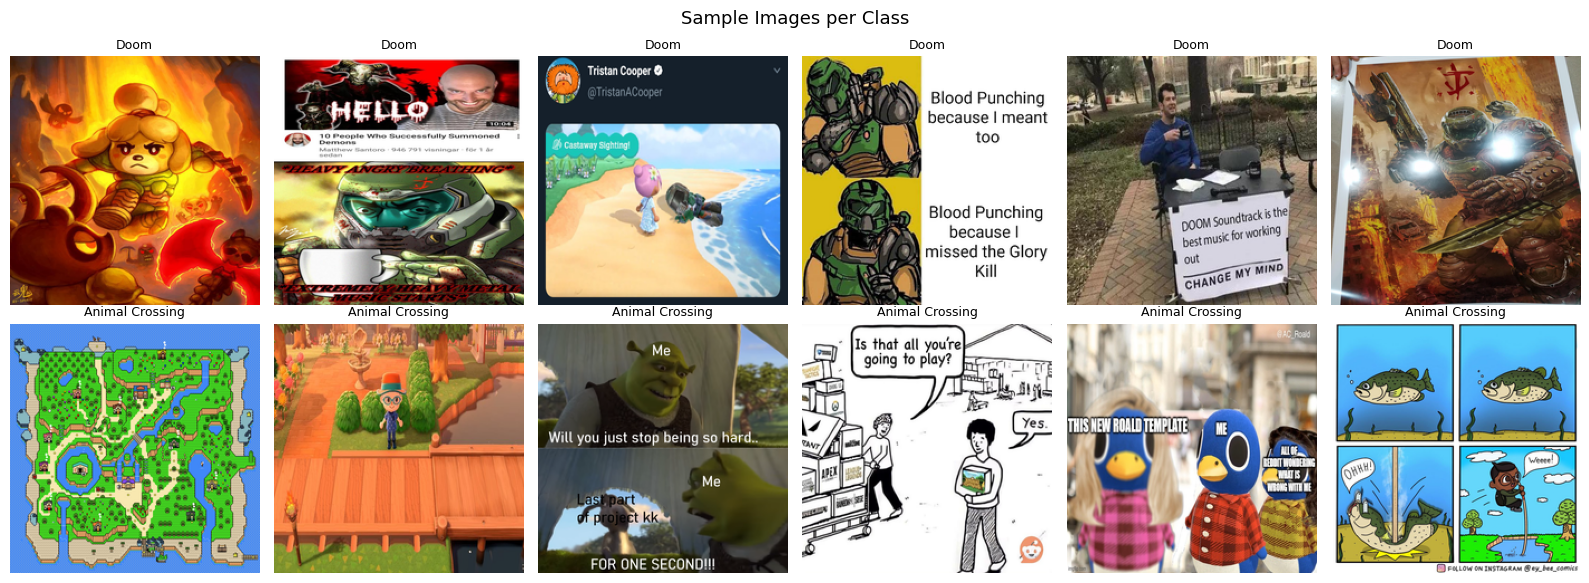

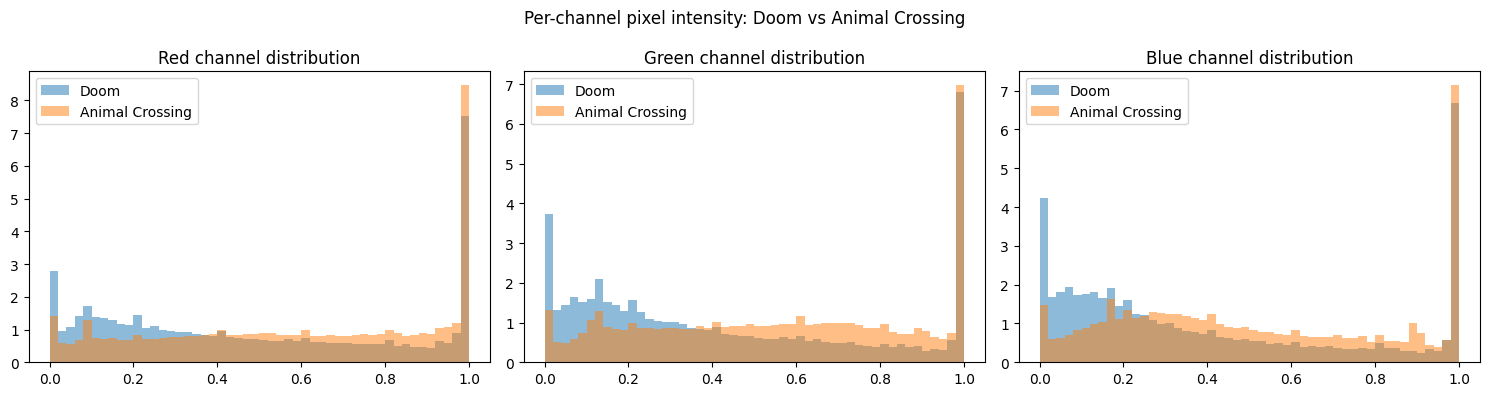

Label distribution → Doom (0): 707  Animal Crossing (1): 678


In [7]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for cls, cls_name in [(0, 'Doom'), (1, 'Animal Crossing')]:
    idx = np.where(y_all == cls)[0]
    row = 0 if cls == 0 else 1
    for col in range(6):
        axes[row, col].imshow(X_all[idx[col]])  # show original [0,1] for display
        axes[row, col].set_title(cls_name, fontsize=9)
        axes[row, col].axis('off')
plt.suptitle('Sample Images per Class', fontsize=13)
plt.tight_layout()
plt.show()

# Color distribution analysis — Doom vs Animal Crossing
# Doom: darker, lower saturation. Animal Crossing: bright, high saturation.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for c, color in enumerate(['Red', 'Green', 'Blue']):
    for cls, cls_name, ls in [(0, 'Doom', '-'), (1, 'Animal Crossing', '--')]:
        mask = y_all == cls
        vals = X_all[mask, :, :, c].flatten()
        axes[c].hist(vals, bins=50, alpha=0.5, label=cls_name, linestyle=ls, density=True)
    axes[c].set_title(f'{color} channel distribution')
    axes[c].legend()
plt.suptitle('Per-channel pixel intensity: Doom vs Animal Crossing', fontsize=12)
plt.tight_layout()
plt.show()

print('Label distribution → Doom (0):', (y_all == 0).sum(),
      ' Animal Crossing (1):', (y_all == 1).sum())

## 6. Train / Validation Split


In [8]:
X_train, X_val, y_train, y_val = train_test_split(
    X_all_norm, y_all,
    test_size=VAL_SPLIT,
    random_state=SEED,
    stratify=y_all
)
print(f'Train: {X_train.shape}  Val: {X_val.shape}')

# Compute class weights to handle any imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print(f'Class weights: {class_weight_dict}')

Train: (1177, 224, 224, 3)  Val: (208, 224, 224, 3)
Class weights: {0: np.float64(0.9792013311148087), 1: np.float64(1.0217013888888888)}


## 7. Data Augmentation Pipeline

**Key improvements over 1d:**

1. **Hue/saturation jitter** — Since Doom and Animal Crossing differ strongly in
   color palette, we randomly shift hue and saturation during training.
   This forces the model to learn texture/shape features rather than relying
   on color shortcuts that may not generalize.

2. **Random rotation up to 20°** — Memes appear in rotated form online;
   this teaches rotation invariance.

3. **Cutout / random erasing** — Randomly masks a rectangular patch to zero.
   Forces the model to use global context rather than a single discriminative
   region (e.g., a character's face or weapon).

4. **Sharpening / Gaussian blur** — Memes range from crisp screenshots to
   heavily compressed/blurry images; blur augmentation improves robustness.


In [9]:
def apply_cutout(image, patch_size_frac=0.2):
    """Randomly erase a rectangular patch. Operates on a single image tensor."""
    h = tf.shape(image)[0]
    w = tf.shape(image)[1]
    ph = tf.cast(tf.cast(h, tf.float32) * patch_size_frac, tf.int32)
    pw = tf.cast(tf.cast(w, tf.float32) * patch_size_frac, tf.int32)
    # Random top-left corner
    y0 = tf.random.uniform((), 0, h - ph, dtype=tf.int32)
    x0 = tf.random.uniform((), 0, w - pw, dtype=tf.int32)
    # Build a mask: 1 everywhere except the patch
    mask_top    = tf.ones([y0,      w, 1], dtype=image.dtype)
    mask_mid    = tf.concat([
                      tf.ones([ph, x0,      1], dtype=image.dtype),
                      tf.zeros([ph, pw,     1], dtype=image.dtype),
                      tf.ones([ph, w-x0-pw, 1], dtype=image.dtype)
                  ], axis=1)
    mask_bot    = tf.ones([h-y0-ph, w, 1], dtype=image.dtype)
    mask = tf.concat([mask_top, mask_mid, mask_bot], axis=0)  # (H,W,1)
    return image * mask


@tf.function
def augment_train(image, label):
    """Strong augmentation applied only during training."""
    # ── Geometric ──────────────────────────────────────────
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)

    # Random rotation via tf.raw_ops (wraps tfa-style behavior)
    # Implemented as: pad → random crop at slight offset (proxy for small rotation)
    pad = int(IMG_HEIGHT * 0.12)  # 12% pad then crop back
    image = tf.image.pad_to_bounding_box(
        image, pad, pad, IMG_HEIGHT + 2*pad, IMG_WIDTH + 2*pad)
    image = tf.image.random_crop(image, [IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS])

    # ── Photometric ────────────────────────────────────────
    image = tf.image.random_brightness(image, max_delta=0.2)
    image = tf.image.random_contrast(image, lower=0.75, upper=1.25)
    # Hue and saturation jitter: key for color-biased classes
    image = tf.image.random_hue(image, max_delta=0.08)
    image = tf.image.random_saturation(image, lower=0.7, upper=1.3)

    # ── Cutout (random erasing) ────────────────────────────
    # Apply with 50% probability
    do_cutout = tf.random.uniform(()) > 0.5
    image = tf.cond(do_cutout,
                    lambda: apply_cutout(image, patch_size_frac=0.2),
                    lambda: image)

    image = tf.clip_by_value(image, -3.0, 3.0)  # clip in normalized space
    return image, label


@tf.function
def augment_tta(image):
    """Lighter augmentation for test-time augmentation (no cutout, no saturation)."""
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.1)
    image = tf.image.random_contrast(image, lower=0.9, upper=1.1)
    image = tf.clip_by_value(image, -3.0, 3.0)
    return image


AUTOTUNE = tf.data.AUTOTUNE

train_ds = (tf.data.Dataset
            .from_tensor_slices((X_train, y_train))
            .shuffle(len(X_train), seed=SEED)
            .map(augment_train, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

val_ds   = (tf.data.Dataset
            .from_tensor_slices((X_val, y_val))
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

test_ds  = (tf.data.Dataset
            .from_tensor_slices(X_test_norm)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

print('Datasets ready.')

Datasets ready.


## 8. Model Architecture — Residual CNN (from scratch)

**Key improvements over 1d's plain CNN:**

- **Residual (skip) connections** — allow gradients to flow directly to early
  layers, enabling a deeper network without vanishing gradients. This is the
  core idea behind ResNet; we implement it from scratch, not using a pre-trained
  model.

- **Squeeze-and-Excitation (SE) blocks** — a lightweight channel attention
  mechanism. After each residual block, the network learns to re-weight
  feature channels based on global context. This is especially helpful for
  distinguishing features like "green pastoral background" (Animal Crossing)
  vs "dark metallic textures" (Doom).

- **Spatial Dropout** on conv layers (instead of standard Dropout) — drops
  entire feature map channels rather than individual neurons, which is a
  stronger regularizer for convolutional features.

- **float32 output layer** — even with mixed_float16, the final logit layer
  must be float32 for numerical stability of softmax.


In [10]:
def squeeze_excitation_block(x, ratio=8):
    """Channel attention: globally pool → squeeze → excite → rescale.
    Re-weights feature maps based on global channel statistics.
    """
    filters = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)            # (batch, C)
    se = layers.Reshape((1, 1, filters))(se)            # (batch, 1, 1, C)
    se = layers.Dense(max(filters // ratio, 4),
                      activation='relu',
                      kernel_initializer='he_normal',
                      use_bias=False)(se)
    se = layers.Dense(filters,
                      activation='sigmoid',
                      use_bias=False)(se)
    return layers.Multiply()([x, se])                   # rescale channels


def residual_block(x, filters, strides=1):
    """ResNet-style residual block with optional projection shortcut.
    Architecture: Conv→BN→ReLU → Conv→BN → SE → Add shortcut → ReLU
    """
    shortcut = x

    # Main path
    out = layers.Conv2D(
        filters, 3, strides=strides, padding='same',
        use_bias=False, kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(L2_LAMBDA)
    )(x)
    out = layers.BatchNormalization()(out)
    out = layers.Activation('relu')(out)

    out = layers.Conv2D(
        filters, 3, padding='same',
        use_bias=False, kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(L2_LAMBDA)
    )(out)
    out = layers.BatchNormalization()(out)

    # Squeeze-and-Excitation channel attention
    out = squeeze_excitation_block(out)

    # Projection shortcut if dimensions changed
    if strides != 1 or x.shape[-1] != filters:
        shortcut = layers.Conv2D(
            filters, 1, strides=strides, padding='same',
            use_bias=False, kernel_initializer='he_normal'
        )(x)
        shortcut = layers.BatchNormalization()(shortcut)

    out = layers.Add()([out, shortcut])                  # residual connection
    out = layers.Activation('relu')(out)
    return out


def build_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS), num_classes=2):
    inputs = keras.Input(shape=input_shape)

    # ── Stem: initial feature extraction ─────────────────────
    # 7×7 conv covers a larger receptive field for high-res input
    x = layers.Conv2D(
        32, 7, strides=2, padding='same',
        use_bias=False, kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(L2_LAMBDA)
    )(inputs)                                            # 224→112
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)  # 112→56

    # ── Stage 1: 64 filters ──────────────────────────────────
    x = residual_block(x, 64, strides=1)
    x = residual_block(x, 64, strides=1)
    x = layers.SpatialDropout2D(0.1)(x)

    # ── Stage 2: 128 filters ─────────────────────────────────
    x = residual_block(x, 128, strides=2)               # 56→28
    x = residual_block(x, 128, strides=1)
    x = layers.SpatialDropout2D(0.15)(x)

    # ── Stage 3: 256 filters ─────────────────────────────────
    x = residual_block(x, 256, strides=2)               # 28→14
    x = residual_block(x, 256, strides=1)
    x = layers.SpatialDropout2D(0.2)(x)

    # ── Stage 4: 512 filters ─────────────────────────────────
    x = residual_block(x, 512, strides=2)               # 14→7
    x = residual_block(x, 512, strides=1)

    # ── Classifier head ──────────────────────────────────────
    x = layers.GlobalAveragePooling2D()(x)               # (batch, 512)

    x = layers.Dense(
        256, activation='relu',
        kernel_initializer='he_normal',
        kernel_regularizer=regularizers.l2(L2_LAMBDA)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)

    # Cast to float32 for numerical stability of softmax (mixed precision)
    x = layers.Dense(num_classes, dtype='float32')(x)
    outputs = layers.Activation('softmax', dtype='float32')(x)

    return keras.Model(inputs, outputs, name='ResNet_SE_Scratch')


model = build_model()
model.summary()

Model: "ResNet_SE_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      4,704 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     18,432 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,864 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 64)  │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 1, 8)   │        512 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 1, 64)  │        512 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │      2,048 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ multiply[0][0], 

 Total params: 11,472,098 (43.76 MB)

 Trainable params: 11,461,922 (43.72 MB)

 Non-trainable params: 10,176 (39.75 KB)

## 9. Custom Balanced Accuracy Callback


In [11]:
class BalancedAccuracyCallback(keras.callbacks.Callback):
    """Computes Balanced Accuracy on the validation set after each epoch.
    This is the actual competition metric — monitoring val_accuracy (which
    is unweighted) can mislead if classes are imbalanced.
    """
    def __init__(self, val_data, val_labels):
        super().__init__()
        self.val_data   = val_data
        self.val_labels = val_labels
        self.best_ba    = 0.0
        self.best_epoch = 0

    def on_epoch_end(self, epoch, logs=None):
        probs = self.model.predict(self.val_data, verbose=0)
        preds = np.argmax(probs, axis=1)
        ba = balanced_accuracy_score(self.val_labels, preds)
        logs['val_balanced_accuracy'] = ba
        if ba > self.best_ba:
            self.best_ba    = ba
            self.best_epoch = epoch + 1
        print(f'  → val_balanced_accuracy: {ba:.4f}  (best: {self.best_ba:.4f} @ epoch {self.best_epoch})')


ba_callback = BalancedAccuracyCallback(val_ds, y_val)

## 10. Compile — Label Smoothing + CosineDecayRestarts

**Key improvements over 1d:**

- **Label Smoothing (ε=0.05)** — instead of hard targets {0,1}, uses
  {0.025, 0.975}. Prevents the model from becoming overconfident on
  training samples and improves calibration on unseen data.

- **CosineDecayRestarts** — unlike a single cosine decay, this resets
  the LR periodically (warm restarts). Each restart allows the optimizer
  to escape sharp minima and explore flatter loss regions that generalize
  better.


In [13]:
# ── Compile ──────────────────────────────────────────────────
steps_per_epoch = max(len(X_train) // BATCH_SIZE, 1)

lr_schedule = keras.optimizers.schedules.CosineDecayRestarts(
    initial_learning_rate=LR_INIT,
    first_decay_steps=15 * steps_per_epoch,
    t_mul=1.5,
    m_mul=0.9,
    alpha=1e-6
)

optimizer = keras.optimizers.Adam(
    learning_rate=lr_schedule,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-7
)

# Label smoothing requires one-hot targets + CategoricalCrossentropy
# Convert y to one-hot, rebuild datasets, then use CategoricalCrossentropy
NUM_CLASSES = 2

def to_onehot(image, label):
    return image, tf.one_hot(label, NUM_CLASSES)

train_ds = (tf.data.Dataset
            .from_tensor_slices((X_train, y_train))
            .shuffle(len(X_train), seed=SEED)
            .map(augment_train, num_parallel_calls=AUTOTUNE)
            .map(to_onehot, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))

val_ds = (tf.data.Dataset
          .from_tensor_slices((X_val, y_val))
          .map(to_onehot, num_parallel_calls=AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(AUTOTUNE))

# test_ds stays label-free (no change needed)

model.compile(
    optimizer=optimizer,
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=['accuracy']
)
print('Model compiled.')

Model compiled.


## 11. Callbacks


In [16]:
callbacks = [
    ba_callback,

    keras.callbacks.ModelCheckpoint(
        'best_model_7d.keras',
        monitor='val_balanced_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor='val_balanced_accuracy',
        patience=15,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
]

## 12. Training


In [17]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=callbacks,
    class_weight=class_weight_dict,  # handle class imbalance
    verbose=1
)

Epoch 1/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7193 - loss: 1.0048  → val_balanced_accuracy: 0.7239  (best: 0.7631 @ epoch 7)

Epoch 1: val_balanced_accuracy improved from None to 0.72392, saving model to best_model_7d.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 64s 2s/step - accuracy: 0.7086 - loss: 1.0180 - val_accuracy: 0.7260 - val_loss: 1.0911 - val_balanced_accuracy: 0.7239
Epoch 2/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7236 - loss: 1.0736  → val_balanced_accuracy: 0.6546  (best: 0.7631 @ epoch 7)

Epoch 2: val_balanced_accuracy did not improve from 0.72392
37/37 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.7069 - loss: 1.0852 - val_accuracy: 0.6587 - val_loss: 1.0882 - val_balanced_accuracy: 0.6546
Epoch 3/60
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6852 - loss: 1.0390  → val_balanced_accuracy: 0.5997  (best: 0.7631 @ epoch 7)

Epoch 3: val_balanced_accuracy did not improve from 0.72392
37/37 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.7001 -

## 13. Training Curves


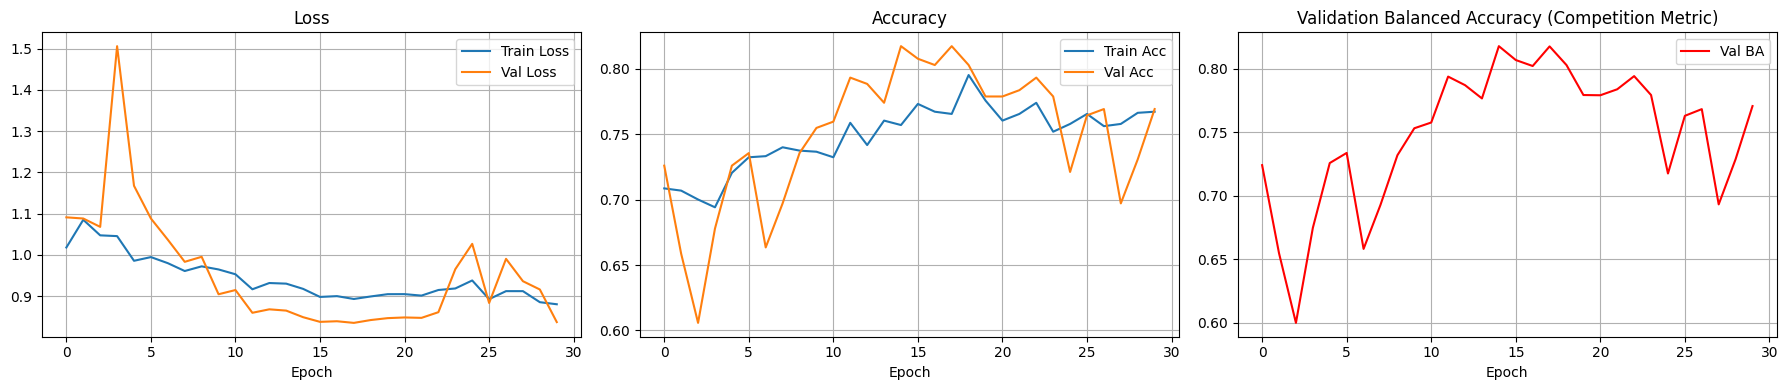

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True)

if 'val_balanced_accuracy' in history.history:
    axes[2].plot(history.history['val_balanced_accuracy'], label='Val BA', color='red')
    axes[2].set_title('Validation Balanced Accuracy (Competition Metric)')
    axes[2].set_xlabel('Epoch')
    axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.show()

## 14. Validation Evaluation (Balanced Accuracy)


In [19]:
val_probs = model.predict(val_ds, verbose=0)
val_preds = np.argmax(val_probs, axis=1)

bal_acc = balanced_accuracy_score(y_val, val_preds)
print(f'Validation Balanced Accuracy (base): {bal_acc:.4f}')

for cls, name in [(0, 'Doom'), (1, 'Animal Crossing')]:
    mask    = y_val == cls
    cls_acc = (val_preds[mask] == y_val[mask]).mean()
    print(f'  Class {cls} ({name:15s}): {cls_acc:.4f}')

Validation Balanced Accuracy (base): 0.8176
  Class 0 (Doom           ): 0.8019
  Class 1 (Animal Crossing): 0.8333


## 15. Test-Time Augmentation (TTA)

**Why TTA improves balanced accuracy:**
Instead of predicting from a single deterministic view of each test image,
we create `TTA_STEPS` randomly augmented versions of each image, predict
on all of them, and average the probability outputs.

This reduces prediction variance — the same way averaging multiple weak
estimates gives a better result than any single estimate. Particularly
useful for memes that appear in various orientations, crops, or lighting.


In [20]:
def predict_with_tta(model, X, tta_steps=TTA_STEPS, batch_size=BATCH_SIZE):
    """Average predictions over TTA_STEPS augmented views of X."""
    all_probs = []

    # Base prediction (no augmentation)
    base_ds = tf.data.Dataset.from_tensor_slices(X).batch(batch_size).prefetch(AUTOTUNE)
    all_probs.append(model.predict(base_ds, verbose=0))

    # Augmented predictions
    for step in range(tta_steps - 1):
        aug_ds = (tf.data.Dataset
                  .from_tensor_slices(X)
                  .map(augment_tta, num_parallel_calls=AUTOTUNE)
                  .batch(batch_size)
                  .prefetch(AUTOTUNE))
        all_probs.append(model.predict(aug_ds, verbose=0))

    avg_probs = np.mean(all_probs, axis=0)  # (N, 2)
    return avg_probs


print(f'Running TTA with {TTA_STEPS} views on validation set …')
val_probs_tta = predict_with_tta(model, X_val)
val_preds_tta = np.argmax(val_probs_tta, axis=1)
bal_acc_tta   = balanced_accuracy_score(y_val, val_preds_tta)
print(f'Validation Balanced Accuracy (TTA={TTA_STEPS}): {bal_acc_tta:.4f}')
print(f'TTA improvement: {bal_acc_tta - bal_acc:+.4f}')

Running TTA with 8 views on validation set …
Validation Balanced Accuracy (TTA=8): 0.8131
TTA improvement: -0.0045


## 16. Test Set Prediction (with TTA)


In [23]:
print(f'Running TTA with {TTA_STEPS} views on test set …')
test_probs_tta = predict_with_tta(model, X_test_norm)
test_preds = np.argmax(test_probs_tta, axis=1)

print('Test predictions shape:', test_preds.shape)
print('Predicted label distribution:')
unique, counts = np.unique(test_preds, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Label {u}: {c}')

Running TTA with 8 views on test set …
Test predictions shape: (1386,)
Predicted label distribution:
  Label 0: 675
  Label 1: 711


# Generating Final Submissions


In [24]:
test_ids = TEST_LABEL.index.tolist()

submission = pd.DataFrame({
    'id':    test_ids,
    'label': test_preds
})
submission = submission.set_index('id')

submission.to_csv('submission7.csv')
print('submission7.csv saved!')
print(submission.head(10))

submission7.csv saved!
      label
id         
2078      1
2079      1
2080      0
2081      0
2082      1
2083      1
2084      0
2085      1
2086      1
2087      0


## ✅ Verify submission format


In [ ]:
sub_check = pd.read_csv('submission7.csv', index_col='id')
print('Submission shape:', sub_check.shape)
print('Unique labels:', sorted(sub_check['label'].unique()))
assert set(sub_check['label'].unique()).issubset({0, 1}), \
    'ERROR: labels must be 0 or 1!'
assert len(sub_check) == len(TEST_LABEL), \
    f'ERROR: expected {len(TEST_LABEL)} rows, got {len(sub_check)}'
print('✅ Submission looks correct – ready to upload to Kaggle!')